# Random Forest Classifier

Building a Random Forest model to predict customer churn
using the Churn Prediction dataset.

Tools: Python | Pandas | Scikit-learn | Matplotlib

In [1]:
import pandas as pd 
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Step 1: Load and Preprocess Dataset
Loading the Churn dataset and encoding categorical columns.
- Label Encoding for State (high cardinality)
- One Hot Encoding for International Plan and Voice Mail Plan
- Boolean columns converted to int using astype(int)

In [2]:
df = pd.read_csv("../../Data Set For Task/Churn Prdiction Data/churn-bigml-80.csv")

In [3]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
df.select_dtypes(include="object").nunique()

State                 51
International plan     2
Voice mail plan        2
dtype: int64

In [5]:
df = pd.get_dummies(df, columns=['International plan', 'Voice mail plan'], drop_first=True, dtype=int)

In [6]:
df.head()

,State,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,International plan_Yes,Voice mail plan_Yes
0,KS,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False,0,1
1,OH,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False,0,1
2,NJ,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False,0,0
3,OH,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False,1,0
4,OK,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False,1,0


In [7]:
df.select_dtypes(include="object").nunique()

State    51
dtype: int64

In [8]:
df = df.rename(columns = {
    "International plan_Yes": "International Plan",
    "Voice mail plan_Yes" : "Voice Mail Plan"
})

In [9]:
le = LabelEncoder()
df['State'] = le.fit_transform(df['State'])

In [10]:
df.head()

,State,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn,International Plan,Voice Mail Plan
0,16,128,415,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False,0,1
1,35,107,415,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False,0,1
2,31,137,415,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False,0,0
3,35,84,408,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False,1,0
4,36,75,415,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False,1,0


## Step 2: Train Test Split
Splitting into 80% training (2132 rows) and 20% testing (534 rows).
Target column: Churn (0 = No Churn, 1 = Churn)

In [11]:
x = df.drop(columns = ['Churn'])
y = df['Churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)
print(x_train.shape)
print(x_test.shape)

(2132, 19)
(534, 19)


## Step 3: Baseline Random Forest Model
Training a default Random Forest with 100 trees.
Each tree trained on random subset of rows (bootstrapping)
and random subset of features (max_features='sqrt').

In [13]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Step 4: Baseline Evaluation
Evaluating default model performance before tuning.
Recall = 0.6582 → catching 66% of actual churners.

In [14]:
y_pred = model.predict(x_test)

print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.4f}')

Accuracy:  0.9457
Precision: 0.9630
Recall:    0.6582
F1 Score:  0.7820


## Step 5: Hyperparameter Tuning (GridSearchCV)
Using GridSearchCV to find optimal hyperparameters.
- 12 combinations tested (2 x 3 x 2)
- cv=5 → each combination trained and tested 5 times
- scoring='recall' → optimizing for recall

In [20]:
param_grid = {
    'n_estimators': [100,200],
    'max_depth': [None, 10, 20],
    'class_weight': [None, 'balanced']
}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='recall')
grid_search.fit(x_train,y_train)
print(f"Best Parameters: {grid_search.best_params_}" )


Best Parameters: {'class_weight': None, 'max_depth': 20, 'n_estimators': 200}


In [16]:
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(x_test)

print("Tuned Model:")
print(f'Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_tuned):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_tuned):.4f}')

Tuned Model:
Accuracy:  0.9476
Precision: 0.9811
Recall:    0.6582
F1 Score:  0.7879


## Step 6: Cross Validation
Evaluating model reliability using 5-fold cross validation.
Mean CV Recall = 0.7121, Std = 0.0318
Low std → model is consistent and stable across folds ✅
Small gap between CV and test score → generalizing well! ✅

In [17]:
cv_scores = cross_val_score(best_model, x_train, y_train, cv=5, scoring="recall")
print(f'CV Scores: {cv_scores}')
print(f'Mean Recall: {cv_scores.mean():.4f}')
print(f'Std: {cv_scores.std():.4f}')

print(f"Best CV Recall: {grid_search.best_score_:.4f}")

CV Scores: [0.66129032 0.69354839 0.75409836 0.72580645 0.72580645]
Mean Recall: 0.7121
Std: 0.0318
Best CV Recall: 0.7121


## Step 7: Feature Importance
Analyzing which features influence churn predictions the most.
Top features: Total day charge (13%), Total day minutes (12%),
Customer service calls (10%), International Plan (9%)
Least important: Area code (0.9%) → could be dropped!

In [18]:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)


                   Feature  Importance
6         Total day charge    0.129979
4        Total day minutes    0.123842
16  Customer service calls    0.099901
17      International Plan    0.091162
9         Total eve charge    0.066597
7        Total eve minutes    0.062411
14        Total intl calls    0.052211
15       Total intl charge    0.047494
13      Total intl minutes    0.045609
10     Total night minutes    0.038237
12      Total night charge    0.037467
1           Account length    0.032593
5          Total day calls    0.032326
11       Total night calls    0.032076
8          Total eve calls    0.029043
3    Number vmail messages    0.027369
0                    State    0.025542
18         Voice Mail Plan    0.017264
2                Area code    0.008872


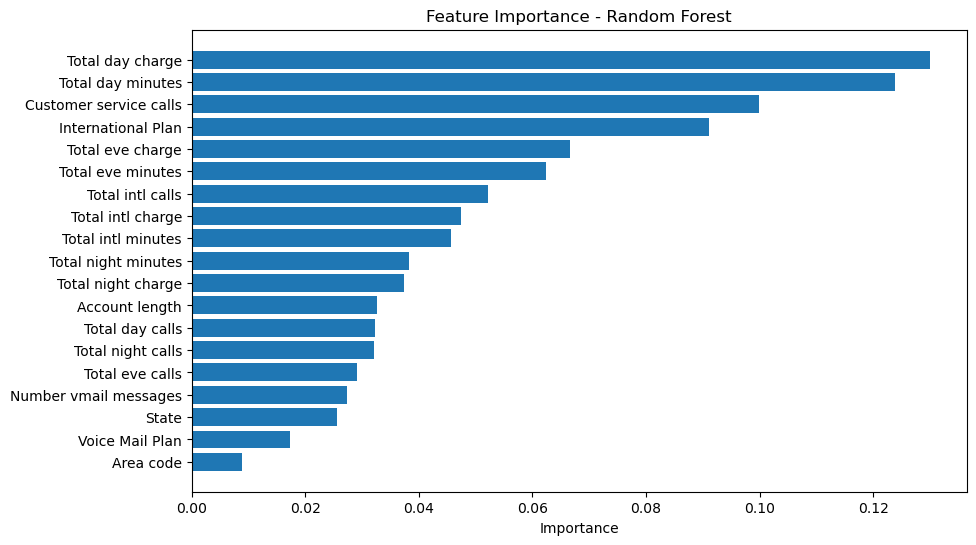

In [22]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.show()